In [8]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

In [22]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # gradient
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other) # wraps integers such as '1' as a Value
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad # ANY CONTRIBUTION TO THE DERIVATIVE IS ACCUMULATED ; solves the problem of multiple references of the same node
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other) # wraps integers such as '1' as a Value
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other): # basically niche fallback for  if can't __mul__ fails
        return self * other # other * self --> self * other AKA 2 * x is now x * 2 and can utilize normal __mul__
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "currently only supporting int/float values for exponentiation"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other-1) * out.grad
        
        out._backward = _backward

        return out
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self): # specifically implemented for the purpose of this example
        x = self.data
        t = (math.exp(2 * x) - 1)/(math.exp(2 * x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):
    
        ## 1) build a topological graph of all nodes: basically constructs a list where all of the children nodes precede the parent node (orders the graph)
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo): ## 2) traverse the graph in reverse order so that we backwards the parent nodes before the children nodes as per the chain rule demands
            node._backward()

In [10]:
a = Value(2.0, label='a')
b = Value(4.0, label='b')

a / b

Value(data=0.5)

In [11]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.lable = 'e'
d = e + c; d.label = 'd'
d


Value(data=4.0)

In [12]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

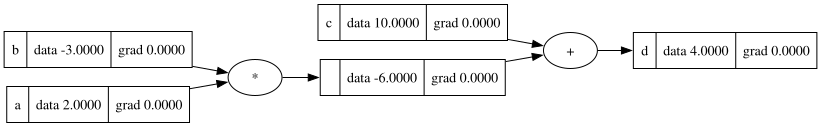

In [21]:
draw_dot(d)

In [20]:
def lol(): # 'staging area' to prevent scope mess-ups

    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0+h, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    # a.data += h
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()



-3.9999999999995595


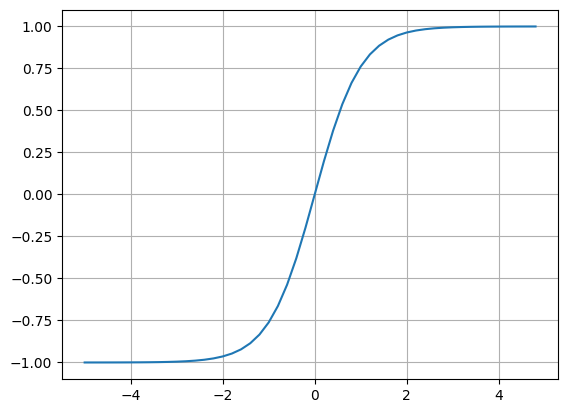

In [15]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid();

In [16]:
## WITH TANH

# inputs x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# neuron's bias
b = Value(6.8813735870195432, label='b')

# neuron function
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o' # 'o' for output

o.backward()

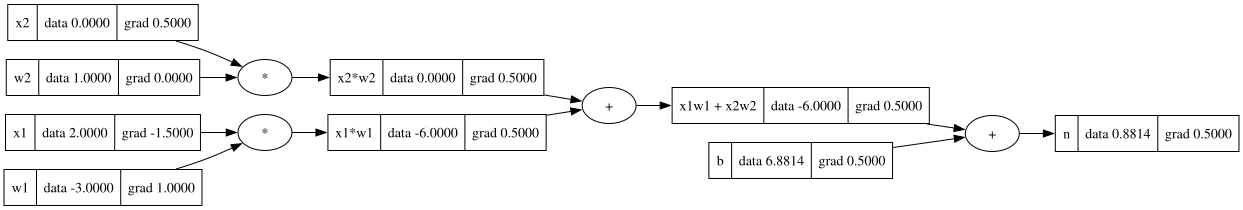

In [17]:
draw_dot(n) # graphviz finally works!


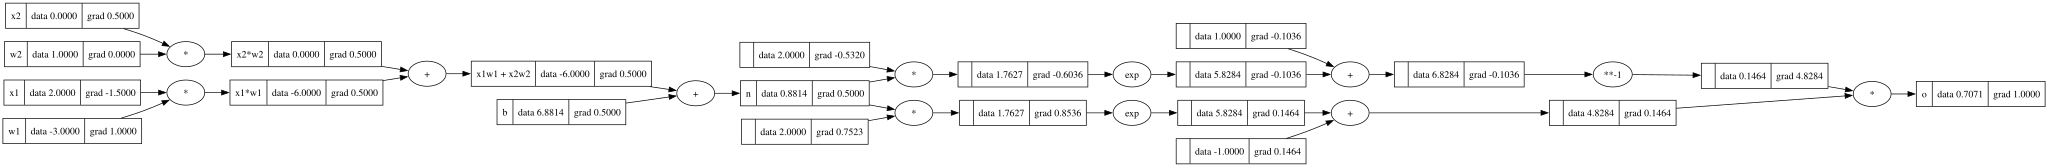

In [18]:
## WITHOUT TANH

# inputs x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# neuron's bias
b = Value(6.8813735870195432, label='b')

# neuron function
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
# e = (2*n).exp()
# o = (e - 1) / (e + 1)
o = ( (2*n).exp() - 1 ) / ( (2*n).exp() + 1 )
# ----
# o = n.tanh(); 
o.label = 'o' # 'o' for output

o.backward()

draw_dot(o)

In [19]:
import torch

ModuleNotFoundError: No module named 'torch'

In [395]:
x1 = torch.Tensor([2.0]).double() # double or 'int64' cuz default is 'int32'                
x1.requires_grad = True # set requires gradient 'True' cuz leaf nodes default is 'False' for efficiency reasons
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [396]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [397]:
class Neuron:

    def __init__(self, nin): # 'nin' AKA 'number of inputs'
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] # random weights
        self.b = Value(random.uniform(-1,1))                       # random bias

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params

    

class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts # 'sz' AKA 'size'
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [398]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
# n(x).backward()

Value(data=0.7902184047408128)

In [399]:
n.parameters()

[Value(data=-0.1366875049507934),
 Value(data=-0.1918169938937242),
 Value(data=0.9821448131464987),
 Value(data=0.6937257222304007),
 Value(data=0.11333972231066491),
 Value(data=0.8265641522583476),
 Value(data=-0.9515911038007654),
 Value(data=-0.30063291239571965),
 Value(data=0.053918075958156564),
 Value(data=-0.8782466093247188),
 Value(data=-0.8684561088898843),
 Value(data=0.7545911813357951),
 Value(data=0.5960334883118312),
 Value(data=0.37897075459011287),
 Value(data=-0.6970594172503344),
 Value(data=0.05820735044067549),
 Value(data=-0.056533780205920925),
 Value(data=0.6939319100399048),
 Value(data=-0.5858635123881057),
 Value(data=0.20377966253721724),
 Value(data=-0.84653110517833),
 Value(data=0.19514321302570647),
 Value(data=0.8353616402976465),
 Value(data=0.06157680143544608),
 Value(data=-0.16963862429130172),
 Value(data=0.9007731041357596),
 Value(data=0.8370429806286461),
 Value(data=-0.6272332883341889),
 Value(data=0.4831219588864972),
 Value(data=0.0037649

In [400]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [401]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]  # predicted outputs
    loss = Value(0.0)
    for v in [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]: # mean squared error for loss
        loss += v

    # backward pass
    for p in n.parameters(): # make sure all grads are reset just like the constructor
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters(): # Stochastic gradient descent
        p.data += -0.05 * p.grad
    print(k, loss.data)

0 0.682101540565228
1 0.2484654137065515
2 0.16804055776285104
3 0.12907316722444237
4 0.10492914195882422
5 0.0882537558043929
6 0.07599375280540847
7 0.06659462357424364
8 0.05916428008762087
9 0.05314893634339554
10 0.04818498287157132
11 0.044023295692160194
12 0.0404873283893636
13 0.03744846000496712
14 0.034810786069488384
15 0.03250136536054519
16 0.030463760413882872
17 0.028653640609117112
18 0.02703571754640144
19 0.025581564323306903


In [402]:
ypred

[Value(data=0.9611777378523607),
 Value(data=-0.9297952331780851),
 Value(data=-0.9102181791429583),
 Value(data=0.8947150929899185)]